In [9]:
from pathlib import Path
import sys
import json
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

cwd = Path.cwd().resolve()
print("Working directory:", cwd)

required = ["cartpole.py", "sf3_week1_week2_review.py"]
missing = [f for f in required if not (cwd / f).exists()]
if missing:
    raise FileNotFoundError(
        "Missing required file(s): " + ", ".join(missing) +
        "\nPut them in the same folder as this notebook."
    )

if str(cwd) not in sys.path:
    sys.path.insert(0, str(cwd))

import sf3_week1_week2_review as sf3
importlib.reload(sf3)

print("Imported helper module successfully.")

Working directory: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4
Imported helper module successfully.


In [12]:
RUN_MODE = "quick"       # change to "full" for final-report quality numbers
RUN_SWEEP = True          # set False only if you are debugging earlier cells
RUN_HYPEROPT = False      # optional; keep False until Step 1 and Step 2 are stable

SEED_DATA = 1
SEED_SPLIT = 123

if RUN_MODE == "quick":
    n_total = 500
    N_train_values = [100, 200, 300]
    M_values = [10, 20, 40, 80]
    centre_seeds = [0, 1]
    rollout_steps = 60
    contour_grid = 41
elif RUN_MODE == "full":
    n_total = 2500
    N_train_values = [300, 600, 1000, 1500]
    M_values = [20, 40, 80, 160, 320]
    centre_seeds = [0, 1, 2, 3, 4]
    rollout_steps = 80
    contour_grid = 91
else:
    raise ValueError("RUN_MODE must be 'quick' or 'full'")

paths = sf3.make_paths(Path.cwd())
print("Output root:", paths.root)
print("Figures:", paths.figures)
print("Logs:", paths.logs)

Output root: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro
Figures: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures
Logs: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/logs


small oscillation: raw theta range=(2.853, 3.426), cycles=0.09
large oscillation: raw theta range=(1.936, 4.377), cycles=0.39
full rotation: raw theta range=(3.142, 49.989), cycles=7.46
Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task1_1_full_rotation_angle_summary.png


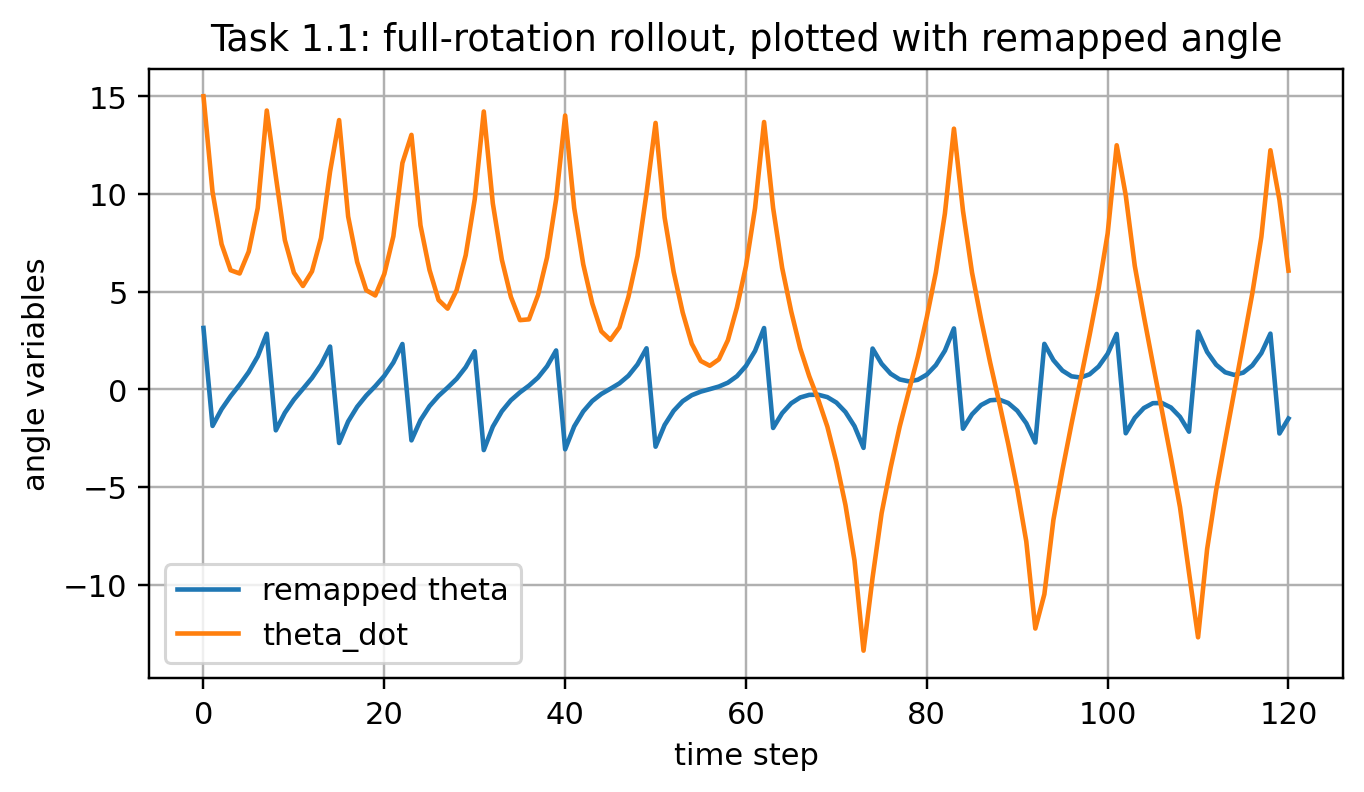

In [15]:
sf3.plot_task1_rollouts(paths)

fig_path = paths.figures / "task1_1_full_rotation_angle_summary.png"
display(Image(filename=str(fig_path)))

Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task1_2_divergent_contour_delta_theta_dot.png


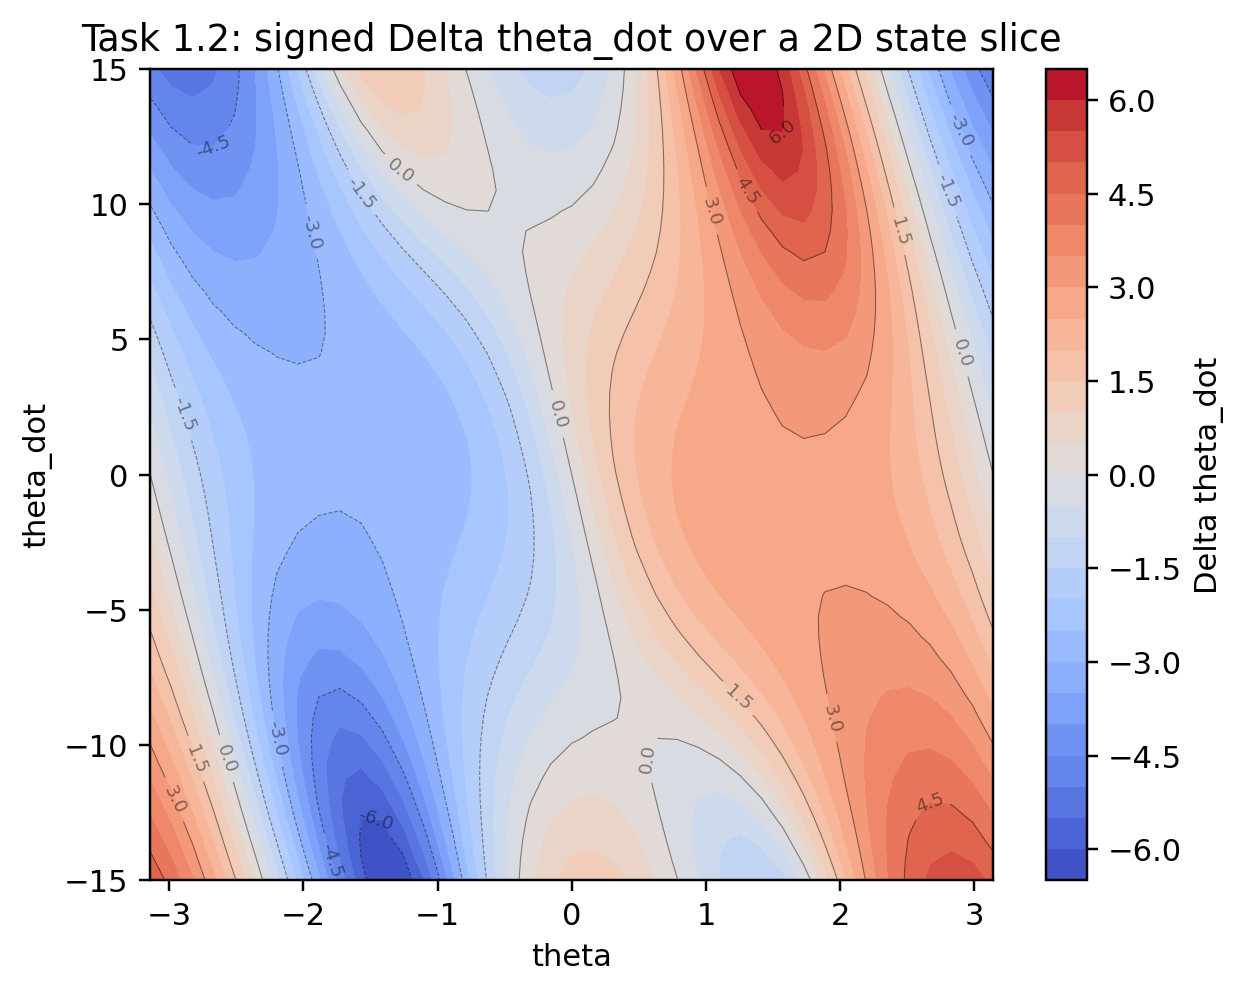

In [18]:
sf3.plot_divergent_contour(
    paths,
    base_state=np.array([0.0, 1.0, 0.0, 0.0]),
    x_index=2,      # theta
    y_index=3,      # theta_dot
    output_dim=3,   # Delta theta_dot
    n_grid=contour_grid,
)

fig_path = paths.figures / "task1_2_divergent_contour_delta_theta_dot.png"
display(Image(filename=str(fig_path)))

In [21]:
dataset_path = paths.data / f"zero_force_{RUN_MODE}_n{n_total}_data{SEED_DATA}_split{SEED_SPLIT}.npz"

if dataset_path.exists():
    print("Loading cached dataset:", dataset_path)
    data = np.load(dataset_path)
    X = data["X_initial"]
    X_next = data["X_next"]
    Y = data["Delta_X"]
    split = sf3.SplitIndices(train=data["train_idx"], val=data["val_idx"], test=data["test_idx"])
else:
    print("Collecting dataset. This may take a little time...")
    X, X_next, Y = sf3.collect_zero_force_dataset(n_total, seed=SEED_DATA)
    split = sf3.make_split_indices(n_total, seed=SEED_SPLIT)
    np.savez(
        dataset_path,
        X_initial=X,
        X_next=X_next,
        Delta_X=Y,
        train_idx=split.train,
        val_idx=split.val,
        test_idx=split.test,
        state_ranges=sf3.STATE_RANGES,
    )
    print("Saved dataset:", dataset_path)

X_train, Y_train = X[split.train], Y[split.train]
X_val, Y_val = X[split.val], Y[split.val]
X_test, Y_test = X[split.test], Y[split.test]

split_table = pd.DataFrame({
    "split": ["train", "validation", "test", "total"],
    "count": [len(X_train), len(X_val), len(X_test), len(X)],
})
display(split_table)

scale_table = pd.DataFrame({
    "target": sf3.DELTA_NAMES,
    "train target std": np.std(Y_train, axis=0),
    "train target mean": np.mean(Y_train, axis=0),
})
display(scale_table)

Saved dataset: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/data/zero_force_quick_n500_data1_split123.npz


,split,count
0,train,300
1,validation,100
2,test,100
3,total,500


,target,train target std,train target mean
0,Delta x,0.596127,-0.000480
1,Delta x_dot,0.893966,0.014215
2,Delta theta,0.867979,0.021275
3,Delta theta_dot,2.665462,-0.161699


In [24]:
raw_linear = sf3.fit_linear_delta_model(X_train, Y_train, feature_kind="raw")
sincos_linear = sf3.fit_linear_delta_model(X_train, Y_train, feature_kind="sincos")

predictions = {
    "raw_linear": {
        "train": sf3.predict_linear_delta(raw_linear, X_train),
        "val": sf3.predict_linear_delta(raw_linear, X_val),
        "test": sf3.predict_linear_delta(raw_linear, X_test),
    },
    "sincos_linear": {
        "train": sf3.predict_linear_delta(sincos_linear, X_train),
        "val": sf3.predict_linear_delta(sincos_linear, X_val),
        "test": sf3.predict_linear_delta(sincos_linear, X_test),
    },
}

metrics = {}
for name, pred in predictions.items():
    metrics[name] = sf3.evaluate_predictions(
        Y_train, Y_val, Y_test,
        pred["train"], pred["val"], pred["test"],
    )

summary_rows = []
for name, m in metrics.items():
    summary_rows.append({
        "model": name,
        "train MSE": m["mse_train"],
        "val MSE": m["mse_val"],
        "test MSE": m["mse_test"],
        "train std-MSE": m["std_mse_train"],
        "val std-MSE": m["std_mse_val"],
        "test std-MSE": m["std_mse_test"],
    })
display(pd.DataFrame(summary_rows))

component_rows = []
for name, m in metrics.items():
    for target, val in zip(sf3.DELTA_NAMES, m["mse_component_test"]):
        component_rows.append({"model": name, "target": target, "test component MSE": val})
component_df = pd.DataFrame(component_rows)
display(component_df.pivot(index="target", columns="model", values="test component MSE"))

Linear model (raw) Phi shape=(300, 5), W shape=(5, 4), rank=5
Linear model (sincos) Phi shape=(300, 6), W shape=(6, 4), rank=6


,model,train MSE,val MSE,test MSE,train std-MSE,val std-MSE,test std-MSE
0,raw_linear,0.969619,0.956838,1.341974,0.292277,0.308058,0.386066
1,sincos_linear,0.620939,0.715882,0.736445,0.206959,0.239174,0.242135


model,raw_linear,sincos_linear
target,,
Delta theta,0.011158,0.006351
Delta theta_dot,4.661025,2.449196
Delta x,0.001833,0.001251
Delta x_dot,0.693882,0.488983


Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task1_3_raw_linear_prediction_vs_truth.png


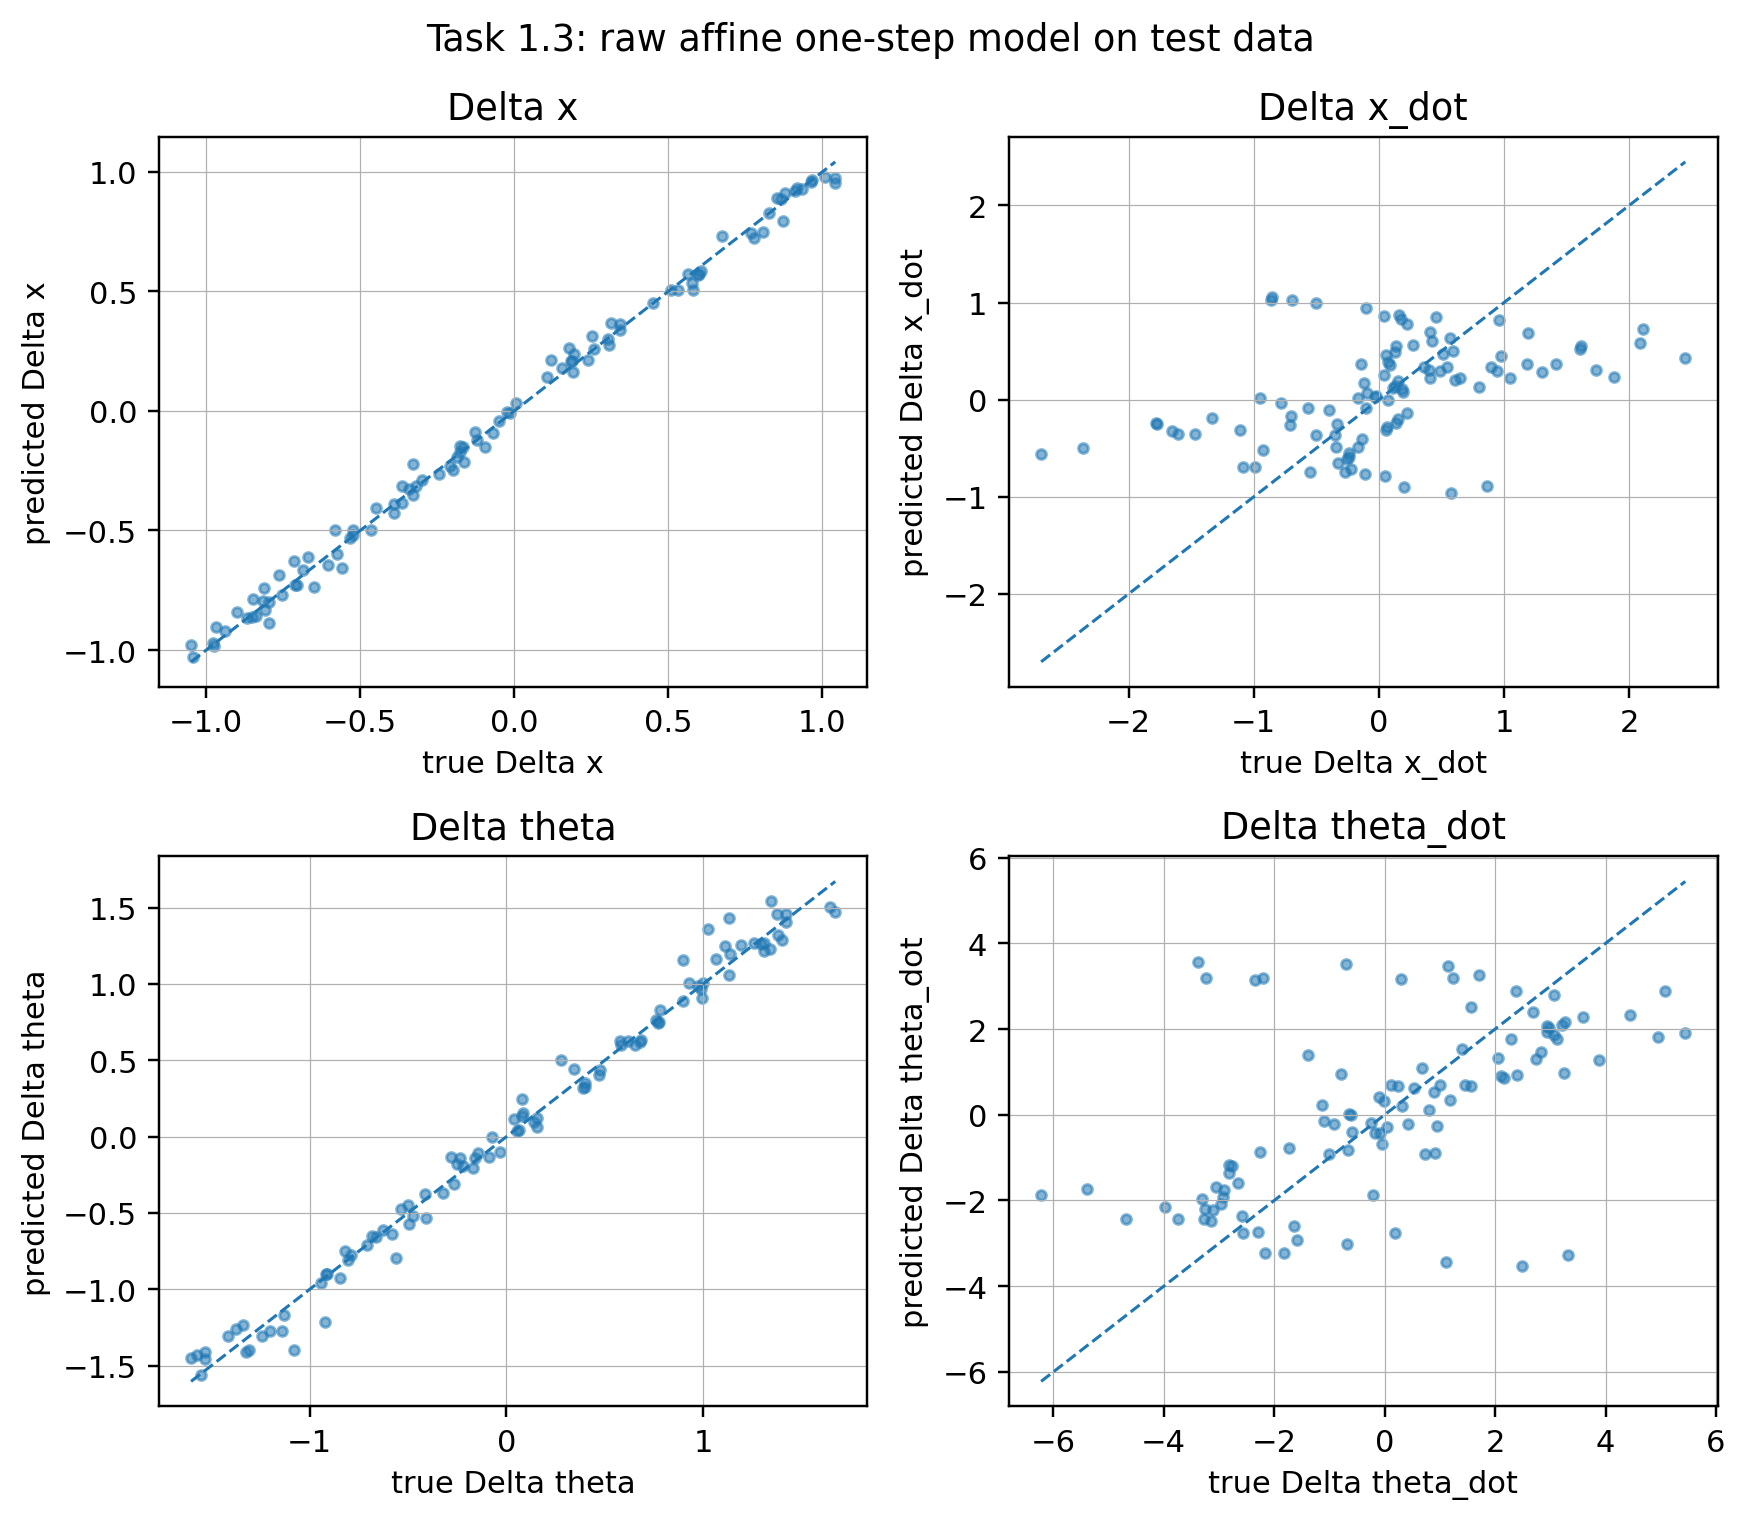

In [26]:
sf3.plot_prediction_vs_truth(
    paths,
    Y_test,
    predictions["raw_linear"]["test"],
    "task1_3_raw_linear_prediction_vs_truth.png",
    "Task 1.3: raw affine one-step model on test data",
)
display(Image(filename=str(paths.figures / "task1_3_raw_linear_prediction_vs_truth.png")))

Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task1_4_raw_linear_rollout_theta.png
Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task1_4_raw_linear_rollout_error.png


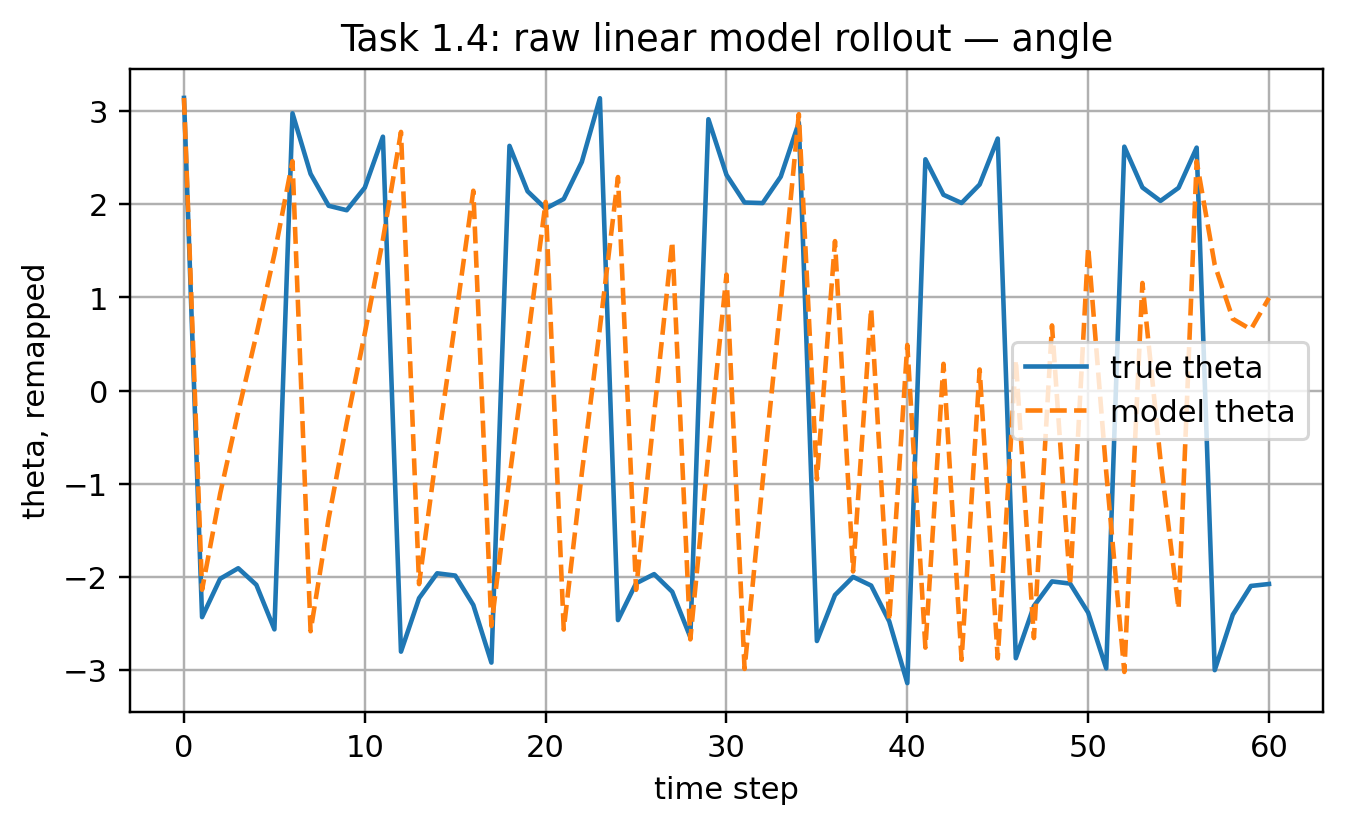

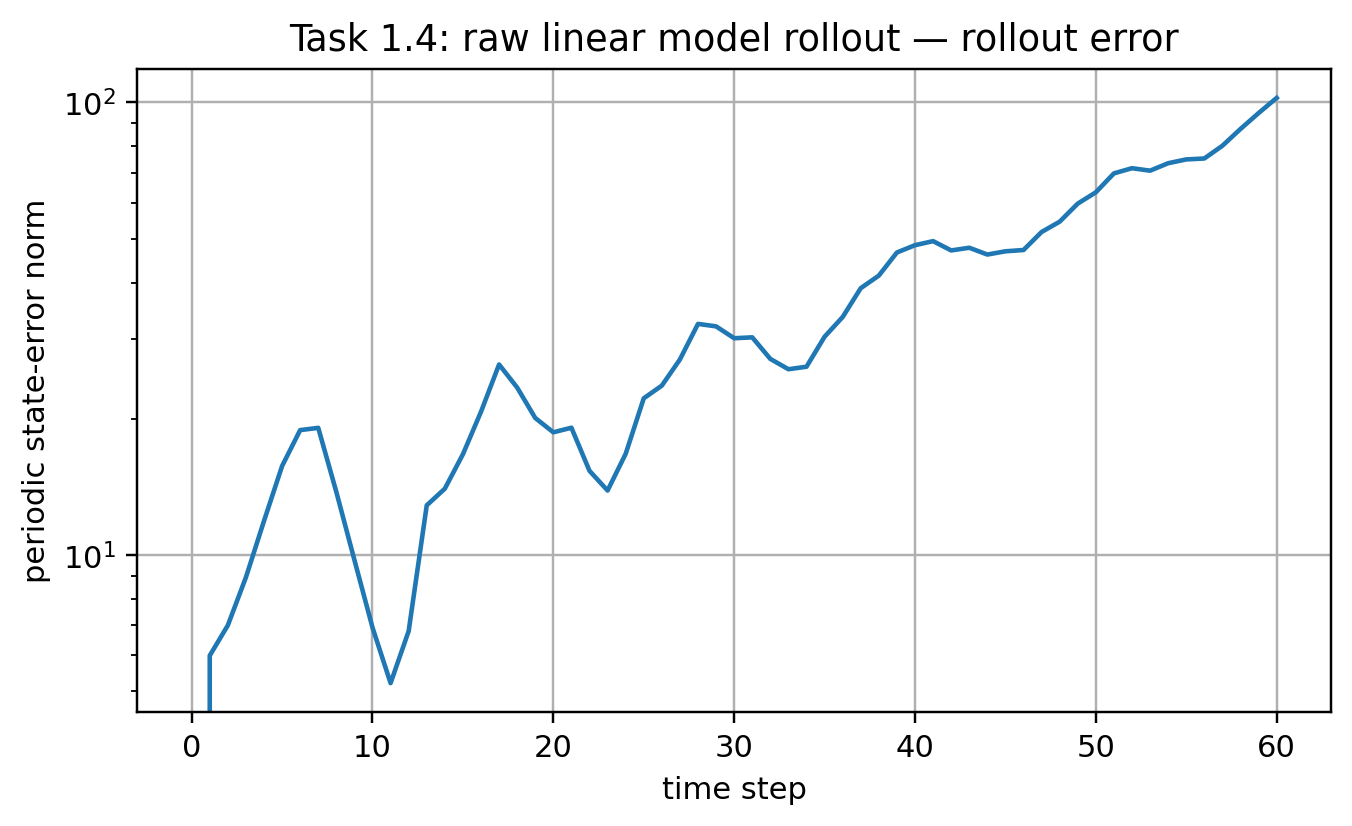

In [29]:
rollout_initial = np.array([0.0, 0.0, np.pi, 8.0])
true_traj = sf3.rollout_true(rollout_initial, rollout_steps)
raw_lin_traj = sf3.rollout_linear_model(
    raw_linear,
    rollout_initial,
    rollout_steps,
    remap_raw_theta_input=True,
)

sf3.plot_rollout_comparison(
    paths,
    true_traj,
    raw_lin_traj,
    "task1_4_raw_linear_rollout.png",
    "Task 1.4: raw linear model rollout",
    max_steps=min(60, rollout_steps),
)
display(Image(filename=str(paths.figures / "task1_4_raw_linear_rollout_theta.png")))
display(Image(filename=str(paths.figures / "task1_4_raw_linear_rollout_error.png")))


Running sweep for raw_periodic_kernel
sweep feature=raw_periodic_kernel N= 100 M=  10 seed=  0 val_std_MSE=0.5634 time=0.00s
sweep feature=raw_periodic_kernel N= 100 M=  10 seed=  1 val_std_MSE=0.5994 time=0.00s
sweep feature=raw_periodic_kernel N= 100 M=  20 seed=  0 val_std_MSE=0.4016 time=0.00s
sweep feature=raw_periodic_kernel N= 100 M=  20 seed=  1 val_std_MSE=0.4483 time=0.00s
sweep feature=raw_periodic_kernel N= 100 M=  40 seed=  0 val_std_MSE=0.3006 time=0.00s
sweep feature=raw_periodic_kernel N= 100 M=  40 seed=  1 val_std_MSE=0.3078 time=0.01s
sweep feature=raw_periodic_kernel N= 100 M=  80 seed=  0 val_std_MSE=0.21 time=0.00s
sweep feature=raw_periodic_kernel N= 100 M=  80 seed=  1 val_std_MSE=0.2308 time=0.00s
sweep feature=raw_periodic_kernel N= 200 M=  10 seed=  0 val_std_MSE=0.5948 time=0.00s
sweep feature=raw_periodic_kernel N= 200 M=  10 seed=  1 val_std_MSE=0.608 time=0.00s
sweep feature=raw_periodic_kernel N= 200 M=  20 seed=  0 val_std_MSE=0.3887 time=0.00s
sweep f

,feature_kind,N_train,M,val_std_mse_mean,val_std_mse_std,test_std_mse_mean,elapsed_seconds_mean,num_repeats
0,raw_periodic_kernel,200,80,0.187494,0.001879,0.225545,0.002924,2


,feature_kind,N_train,M,val_std_mse_mean,val_std_mse_std,test_std_mse_mean,elapsed_seconds_mean,num_repeats
0,raw_periodic_kernel,100,10,0.581419,0.017970,0.661811,0.000519,2
1,raw_periodic_kernel,100,20,0.424969,0.023378,0.613863,0.000565,2
2,raw_periodic_kernel,100,40,0.304193,0.003605,0.518761,0.007155,2
3,raw_periodic_kernel,100,80,0.220392,0.010408,0.322983,0.002023,2
4,raw_periodic_kernel,200,10,0.601421,0.006626,0.593939,0.000305,2
5,raw_periodic_kernel,200,20,0.382577,0.006078,0.423178,0.000577,2
6,raw_periodic_kernel,200,40,0.261150,0.004713,0.364584,0.001796,2
7,raw_periodic_kernel,200,80,0.187494,0.001879,0.225545,0.002924,2
8,raw_periodic_kernel,300,10,0.558369,0.007630,0.578381,0.000596,2
9,raw_periodic_kernel,300,20,0.475689,0.009329,0.538389,0.000705,2


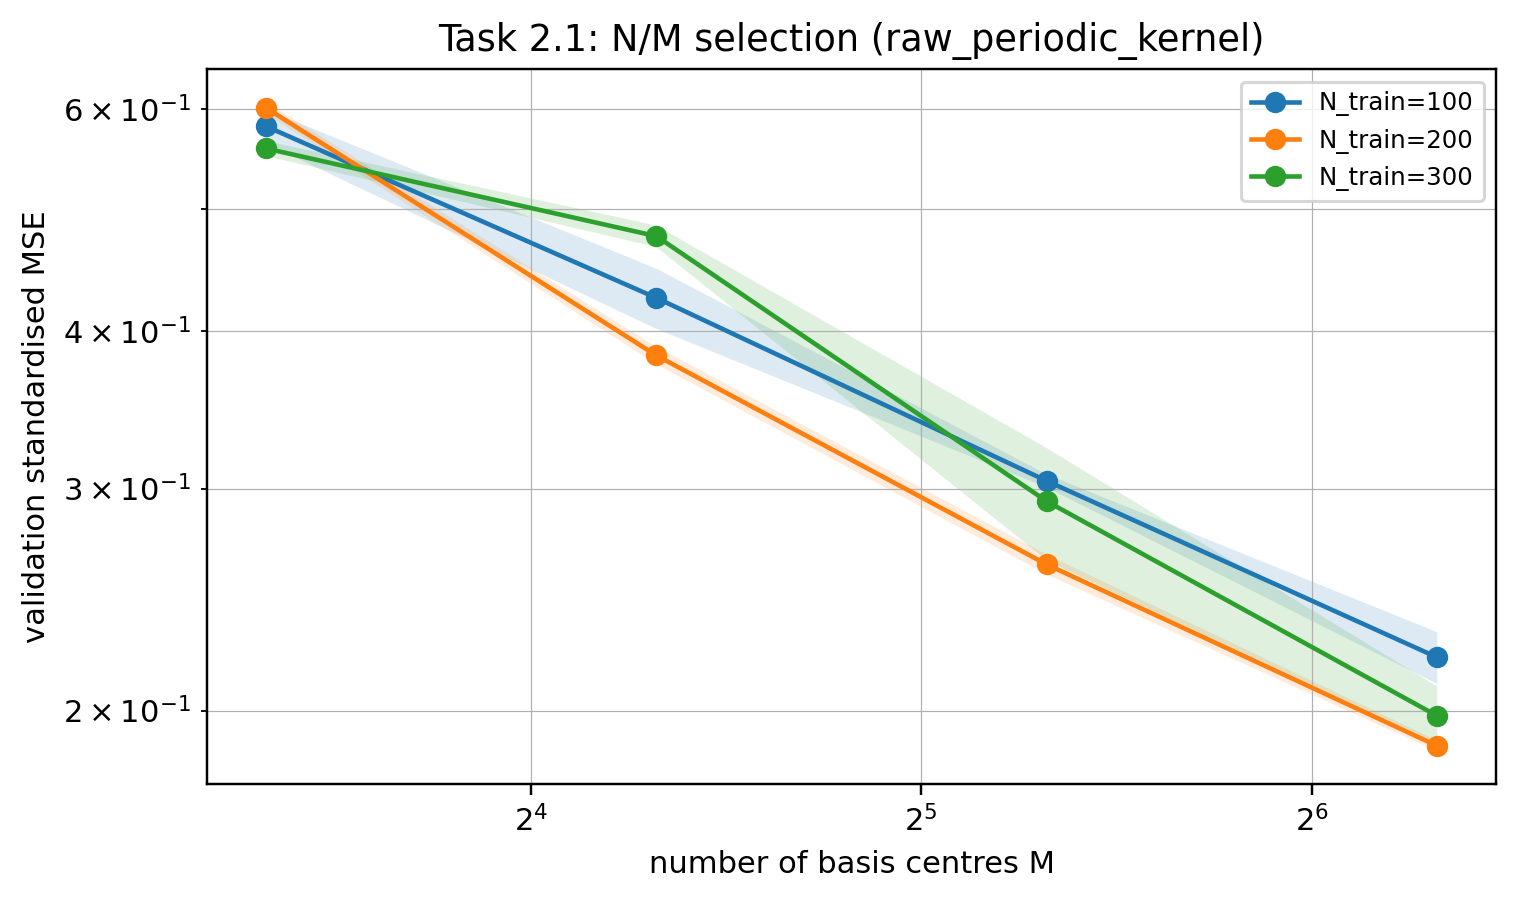


Running sweep for sincos_features
sweep feature=sincos_features N= 100 M=  10 seed=  0 val_std_MSE=0.6007 time=0.00s
sweep feature=sincos_features N= 100 M=  10 seed=  1 val_std_MSE=0.6377 time=0.00s
sweep feature=sincos_features N= 100 M=  20 seed=  0 val_std_MSE=0.3055 time=0.00s
sweep feature=sincos_features N= 100 M=  20 seed=  1 val_std_MSE=0.4563 time=0.01s
sweep feature=sincos_features N= 100 M=  40 seed=  0 val_std_MSE=0.2322 time=0.00s
sweep feature=sincos_features N= 100 M=  40 seed=  1 val_std_MSE=0.3162 time=0.00s
sweep feature=sincos_features N= 100 M=  80 seed=  0 val_std_MSE=0.1599 time=0.01s
sweep feature=sincos_features N= 100 M=  80 seed=  1 val_std_MSE=0.1353 time=0.00s
sweep feature=sincos_features N= 200 M=  10 seed=  0 val_std_MSE=0.6063 time=0.00s
sweep feature=sincos_features N= 200 M=  10 seed=  1 val_std_MSE=0.65 time=0.00s
sweep feature=sincos_features N= 200 M=  20 seed=  0 val_std_MSE=0.4193 time=0.00s
sweep feature=sincos_features N= 200 M=  20 seed=  1 v

,feature_kind,N_train,M,val_std_mse_mean,val_std_mse_std,test_std_mse_mean,elapsed_seconds_mean,num_repeats
0,sincos_features,200,80,0.130384,0.017033,0.141483,0.002449,2


,feature_kind,N_train,M,val_std_mse_mean,val_std_mse_std,test_std_mse_mean,elapsed_seconds_mean,num_repeats
0,sincos_features,100,10,0.619202,0.018478,0.672595,0.001844,2
1,sincos_features,100,20,0.380896,0.075414,0.492229,0.004398,2
2,sincos_features,100,40,0.274216,0.041991,0.363037,0.001504,2
3,sincos_features,100,80,0.147592,0.012297,0.220315,0.004605,2
4,sincos_features,200,10,0.628134,0.021857,0.655682,0.002217,2
5,sincos_features,200,20,0.408793,0.010492,0.422590,0.001629,2
6,sincos_features,200,40,0.230273,0.004568,0.308115,0.001312,2
7,sincos_features,200,80,0.130384,0.017033,0.141483,0.002449,2
8,sincos_features,300,10,0.533167,0.051208,0.615639,0.000405,2
9,sincos_features,300,20,0.485814,0.000864,0.472113,0.000717,2


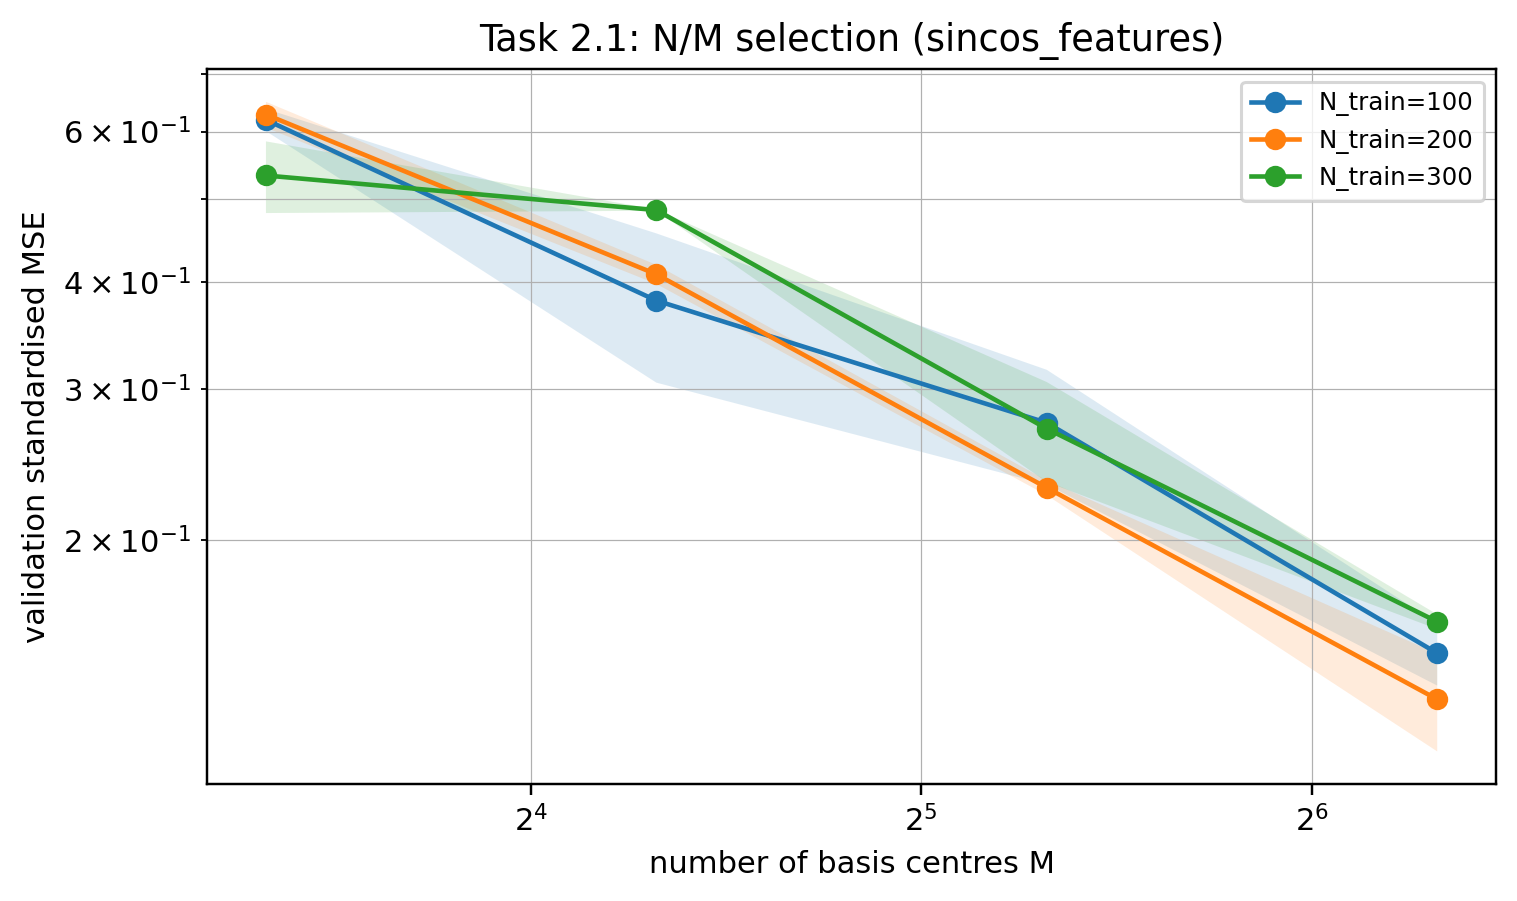

In [32]:
sweep_results = {}
sweep_summaries = {}
chosen_models = {}

if RUN_SWEEP:
    for feature_kind in ["raw_periodic_kernel", "sincos_features"]:
        print("\nRunning sweep for", feature_kind)
        results = sf3.run_m_n_sweep(
            X,
            Y,
            N_train_values=N_train_values,
            M_values=M_values,
            split_seed=SEED_SPLIT,
            centre_seeds=centre_seeds,
            feature_kind=feature_kind,
            reg_strength=1e-3,
        )
        summary = sf3.aggregate_sweep(results)
        chosen = sf3.choose_model_by_one_standard_error(summary)

        sweep_results[feature_kind] = results
        sweep_summaries[feature_kind] = summary
        chosen_models[feature_kind] = chosen

        pd.DataFrame(results).to_csv(paths.logs / f"raw_sweep_rows_{feature_kind}_{RUN_MODE}.csv", index=False)
        pd.DataFrame(summary).to_csv(paths.logs / f"sweep_summary_{feature_kind}_{RUN_MODE}.csv", index=False)
        with open(paths.logs / f"sweep_choice_{feature_kind}_{RUN_MODE}.json", "w") as f:
            json.dump(chosen, f, indent=2)

        sf3.plot_m_n_summary(paths, summary, f"task2_1_m_n_selection_{feature_kind}_{RUN_MODE}.png")
        print("Chosen by one-standard-error rule:")
        display(pd.DataFrame([chosen]))
        display(pd.DataFrame(summary))
        display(Image(filename=str(paths.figures / f"task2_1_m_n_selection_{feature_kind}_{RUN_MODE}.png")))
else:
    print("RUN_SWEEP is False; skipping M/N sweep.")

In [34]:
if RUN_SWEEP and "sincos_features" in chosen_models:
    chosen_sc = chosen_models["sincos_features"]
    N_final = int(chosen_sc["N_train"])
    M_final = int(chosen_sc["M"])
    print("Using chosen sin/cos kernel settings:", chosen_sc)
else:
    N_final = min(300 if RUN_MODE == "quick" else 1500, X_train.shape[0])
    M_final = min(80 if RUN_MODE == "quick" else 160, N_final)
    print("Using fallback settings:", {"N_train": N_final, "M": M_final})

X_train_final = X_train[:N_final]
Y_train_final = Y_train[:N_final]

kernel_sc = sf3.fit_sparse_kernel_model(
    X_train_final,
    Y_train_final,
    M=M_final,
    reg_strength=1e-3,
    seed=456,
    feature_kind="sincos_features",
)

pred_kernel = {
    "train": sf3.predict_sparse_kernel_model(kernel_sc, X_train_final),
    "val": sf3.predict_sparse_kernel_model(kernel_sc, X_val),
    "test": sf3.predict_sparse_kernel_model(kernel_sc, X_test),
}

# Evaluate against the same training subset used to fit this kernel model.
kernel_metrics = sf3.evaluate_predictions(
    Y_train_final, Y_val, Y_test,
    pred_kernel["train"], pred_kernel["val"], pred_kernel["test"],
)
metrics["sincos_kernel"] = kernel_metrics

model_summary = []
for name, m in metrics.items():
    model_summary.append({
        "model": name,
        "train MSE": m["mse_train"],
        "val MSE": m["mse_val"],
        "test MSE": m["mse_test"],
        "train std-MSE": m["std_mse_train"],
        "val std-MSE": m["std_mse_val"],
        "test std-MSE": m["std_mse_test"],
    })
model_summary_df = pd.DataFrame(model_summary)
display(model_summary_df)

per_component_rows = []
for name, m in metrics.items():
    for target, raw_mse, std_mse in zip(sf3.DELTA_NAMES, m["mse_component_test"], m.get("std_mse_component_test", np.nan*np.ones(4))):
        per_component_rows.append({
            "model": name,
            "target": target,
            "test component MSE": raw_mse,
            "test standardised component MSE": std_mse,
        })
per_component_df = pd.DataFrame(per_component_rows)
display(per_component_df.pivot(index="target", columns="model", values="test standardised component MSE"))

Using chosen sin/cos kernel settings: {'feature_kind': 'sincos_features', 'N_train': 200, 'M': 80, 'val_std_mse_mean': 0.13038371351633918, 'val_std_mse_std': 0.017032521640516822, 'test_std_mse_mean': 0.1414830554428304, 'elapsed_seconds_mean': 0.002449417021125555, 'num_repeats': 2}


,model,train MSE,val MSE,test MSE,train std-MSE,val std-MSE,test std-MSE
0,raw_linear,0.969619,0.956838,1.341974,0.292277,0.308058,0.386066
1,sincos_linear,0.620939,0.715882,0.736445,0.206959,0.239174,0.242135
2,sincos_kernel,0.116864,0.299856,0.360852,0.051460,0.113743,0.138235


model,raw_linear,sincos_kernel,sincos_linear
target,,,
Delta theta,0.014810,0.077330,0.008429
Delta theta_dot,0.656049,0.157802,0.344730
Delta x,0.005158,0.089881,0.003522
Delta x_dot,0.868248,0.227929,0.611860


Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task2_3_sincos_kernel_prediction_vs_truth_quick.png


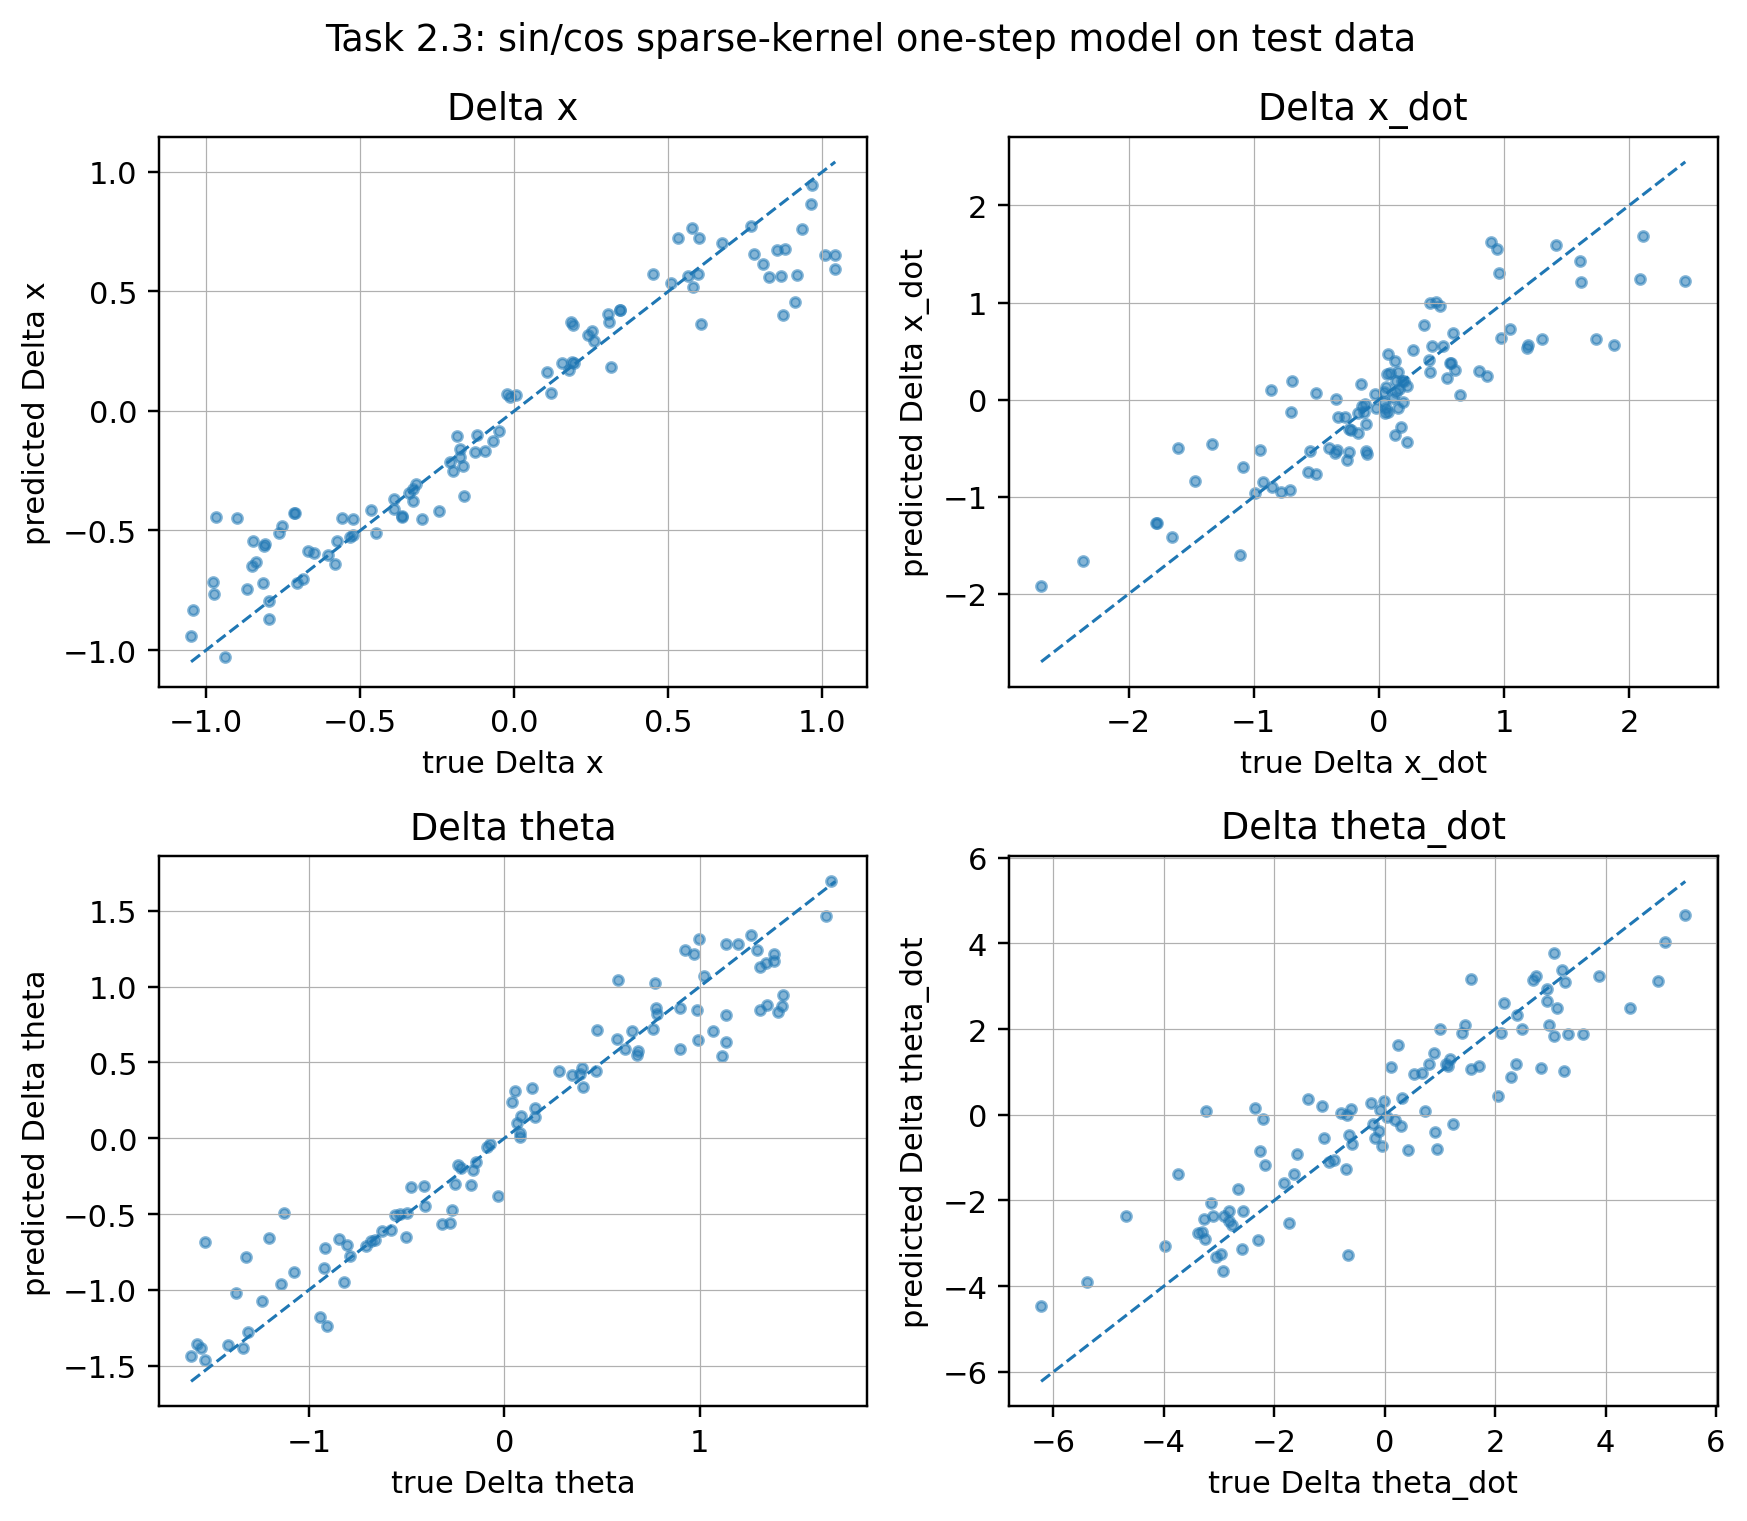

In [37]:
sf3.plot_prediction_vs_truth(
    paths,
    Y_test,
    pred_kernel["test"],
    f"task2_3_sincos_kernel_prediction_vs_truth_{RUN_MODE}.png",
    "Task 2.3: sin/cos sparse-kernel one-step model on test data",
)
display(Image(filename=str(paths.figures / f"task2_3_sincos_kernel_prediction_vs_truth_{RUN_MODE}.png")))

Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task2_3_sincos_kernel_rollout_quick_theta.png
Saved figure: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures/task2_3_sincos_kernel_rollout_quick_error.png


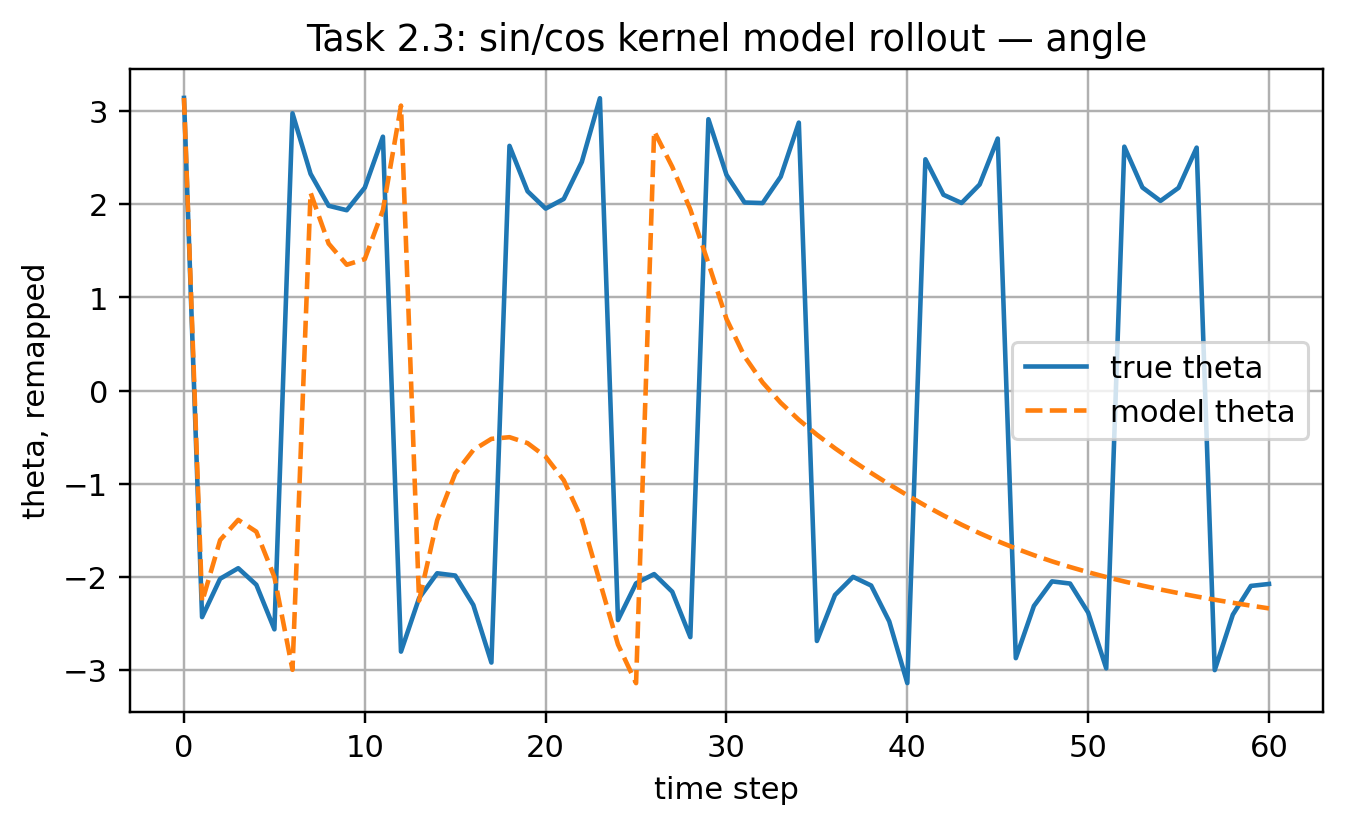

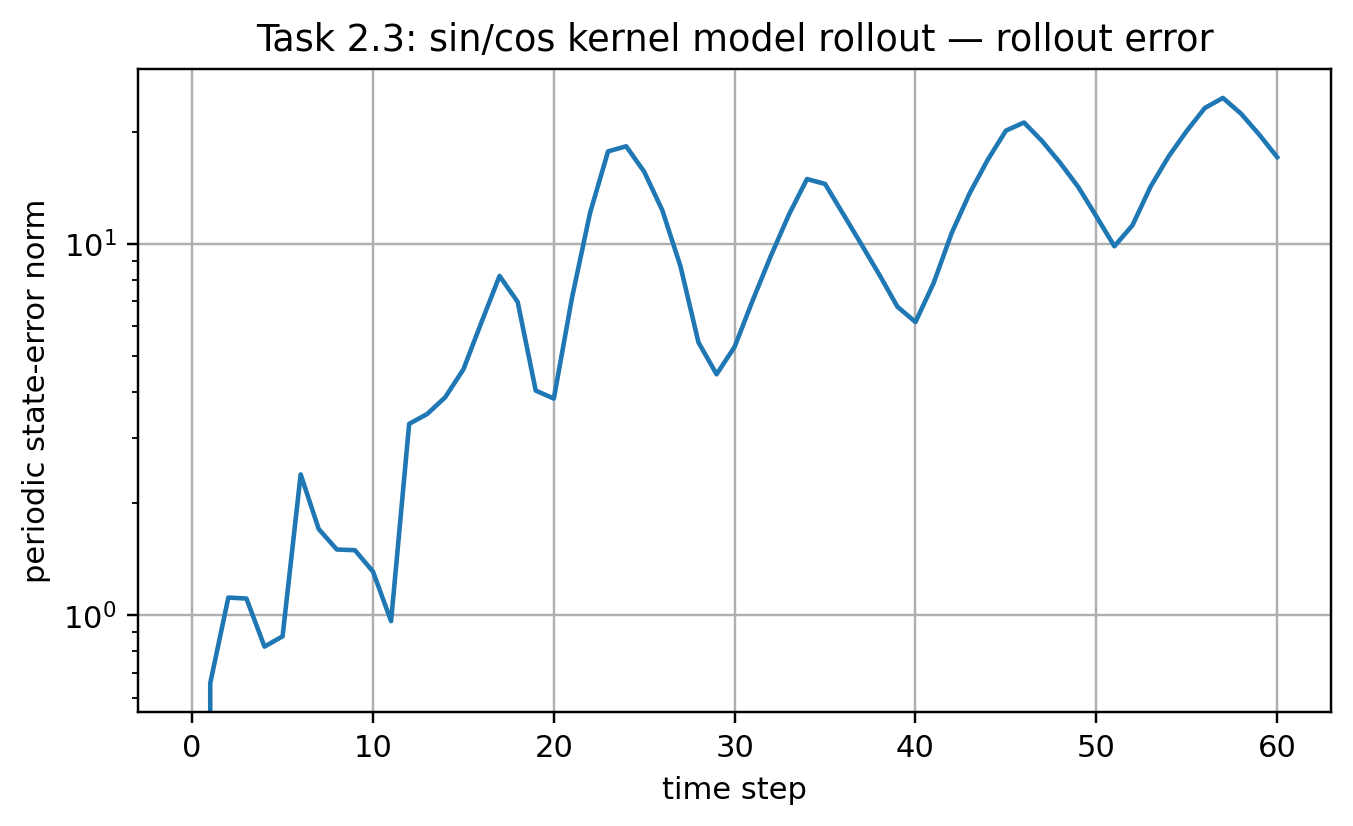

Raw linear rollout horizon:


,threshold,step,time units,approx. raw-theta cycles by that step,status
0,0.5,1,0.1,0.113134,first exceeded
1,1.0,1,0.1,0.113134,first exceeded
2,2.0,1,0.1,0.113134,first exceeded
3,5.0,1,0.1,0.113134,first exceeded


Sin/cos kernel rollout horizon:


,threshold,step,time units,approx. raw-theta cycles by that step,status
0,0.5,1,0.1,0.113134,first exceeded
1,1.0,2,0.2,0.178684,first exceeded
2,2.0,6,0.6,0.026304,first exceeded
3,5.0,16,1.6,0.133815,first exceeded


In [40]:
def rollout_horizon_table(true_traj, pred_traj, thresholds=(0.5, 1.0, 2.0, 5.0)):
    err = sf3.state_error_norm(true_traj, pred_traj)
    rows = []
    for threshold in thresholds:
        above = np.where(err > threshold)[0]
        if len(above) == 0:
            step = len(err) - 1
            status = "not exceeded"
        else:
            step = int(above[0])
            status = "first exceeded"
        time_units = 0.1 * step  # one performAction call corresponds to 0.1 in cartpole.py
        cycles = abs(true_traj[step, 2] - true_traj[0, 2]) / (2*np.pi)
        rows.append({
            "threshold": threshold,
            "step": step,
            "time units": time_units,
            "approx. raw-theta cycles by that step": cycles,
            "status": status,
        })
    return pd.DataFrame(rows)

kernel_traj = sf3.rollout_kernel_model(kernel_sc, rollout_initial, rollout_steps)
sf3.plot_rollout_comparison(
    paths,
    true_traj,
    kernel_traj,
    f"task2_3_sincos_kernel_rollout_{RUN_MODE}.png",
    "Task 2.3: sin/cos kernel model rollout",
    max_steps=min(60, rollout_steps),
)

display(Image(filename=str(paths.figures / f"task2_3_sincos_kernel_rollout_{RUN_MODE}_theta.png")))
display(Image(filename=str(paths.figures / f"task2_3_sincos_kernel_rollout_{RUN_MODE}_error.png")))

print("Raw linear rollout horizon:")
display(rollout_horizon_table(true_traj, raw_lin_traj))
print("Sin/cos kernel rollout horizon:")
display(rollout_horizon_table(true_traj, kernel_traj))

In [43]:
model_summary_df.to_csv(paths.logs / f"week12_step1_model_summary_{RUN_MODE}.csv", index=False)
per_component_df.to_csv(paths.logs / f"week12_step1_per_component_{RUN_MODE}.csv", index=False)

serialisable_metrics = {}
for name, m in metrics.items():
    serialisable_metrics[name] = {
        k: (v.tolist() if isinstance(v, np.ndarray) else v)
        for k, v in m.items()
    }
with open(paths.logs / f"week12_step1_metrics_{RUN_MODE}.json", "w") as f:
    json.dump(serialisable_metrics, f, indent=2)

print("Saved summary files under", paths.logs)
print("Saved figures under", paths.figures)
print("Step 1 complete.")

Saved summary files under /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/logs
Saved figures under /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro/figures
Step 1 complete.
